# Unblinded búsqueda

In [54]:
!pip install -U "huggingface_hub>=1.3.0" sam3 gTTS pydub edge-tts --quiet
!pip install fastapi nest-asyncio pyngrok uvicorn python-multipart Groq pygame --quiet
!apt-get install -y libasound-dev libportaudio2 libportaudiocpp0 portaudio19-dev ffmpeg > /dev/null
!pip install PyAudio SpeechRecognition --quiet

In [55]:
import huggingface_hub
import transformers
import sam3
import requests
from PIL import Image
from io import BytesIO
import torch
from PIL import Image
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
import os
import requests
from google.colab import userdata
from huggingface_hub import login
import numpy as np
from google.colab import files
import matplotlib
from IPython.display import display, Javascript
from google.colab import output
import base64
import nest_asyncio
from fastapi import FastAPI, Response
from pyngrok import ngrok
import uvicorn
import cv2
import numpy as np
import io
from groq import Groq
import re
from datetime import datetime
import time
import os
from gtts import gTTS
import pygame
import speech_recognition as sr
import os
from PIL import Image
import base64
import speech_recognition as sr
from pydub import AudioSegment
from IPython.display import Audio, display

### Funciones de SAM3

In [56]:
def ImageToImage(img, prompt):
  # 1. Definimos la ruta que el error reclama
  target_dir = "/usr/local/lib/python3.12/dist-packages/assets/"
  target_file = os.path.join(target_dir, "bpe_simple_vocab_16e6.txt.gz")

  # 2. Creamos el directorio si no existe
  !sudo mkdir -p {target_dir}
  !sudo chmod 777 {target_dir}

  # 3. Descargamos el archivo que falta
  url = "https://github.com/openai/CLIP/raw/main/clip/bpe_simple_vocab_16e6.txt.gz"

  response = requests.get(url)
  with open(target_file, "wb") as f:
      f.write(response.content)

  # Load the model
  model = build_sam3_image_model()
  processor = Sam3Processor(model)

  inference_state = processor.set_image(image)
  # Prompt the model with text

  output = processor.set_text_prompt(state=inference_state, prompt=prompt)

  # Get the masks, bounding boxes, and scores
  masks, boxes, scores = output["masks"], output["boxes"], output["scores"]

  return masks

In [57]:
def overlay_masks(image, masks):
    image = image.convert("RGBA")
    # Pasamos a numpy y aseguramos tipo uint8
    masks_np = masks.cpu().numpy().astype(np.uint8)

    # Si masks tiene una dimensión extra vacía (ej. 1, H, W), la eliminamos
    if masks_np.ndim == 4: # Caso [N, 1, H, W]
        masks_np = np.squeeze(masks_np, axis=1)

    n_masks = masks_np.shape[0]
    cmap = matplotlib.colormaps.get_cmap("rainbow").resampled(n_masks)

    for i in range(n_masks):
        mask_2d = masks_np[i]
        # Si por alguna razón sigue siendo (1, H, W), forzamos (H, W)
        if mask_2d.ndim == 3:
            mask_2d = mask_2d.squeeze()

        color = tuple(int(c * 255) for c in cmap(i)[:3])

        # Crear la máscara de Pillow
        mask_img = Image.fromarray(mask_2d)

        # Crear capa de color
        overlay = Image.new("RGBA", image.size, color + (0,))

        # Definir transparencia (alpha): donde hay máscara, 50% de opacidad (127)
        alpha = mask_img.point(lambda v: 127 if v > 0 else 0)
        overlay.putalpha(alpha)

        # Combinar
        image = Image.alpha_composite(image, overlay)

    return image

## Funciones de apoyo

In [58]:
def ask_Groq(prompt=None, img_path=None, Danger=False):
    try:
        if img_path is None and Danger == False:
            chat_completion = client.chat.completions.create(
                messages=[
                    {
                        "role": "system",
                        "content": (
                            "REGLAS ESTRICTAS: "
                            "1. NUNCA uses saludos, introducciones (como 'Aquí tienes', 'Me encantaría describir', 'En la imagen se ve') ni despedidas. "
                            "2. Sé extremadamente preciso, objetivo y ve directo al grano. "
                        )
                    },
                    {"role": "user", "content": prompt}
                ],
                model="llama-3.3-70b-versatile",
            )

            return chat_completion.choices[0].message.content

        elif img_path is None and Danger:
            chat_completion = client.chat.completions.create(
                messages=[
                    {
                        "role": "system",
                        "content": (
                            "Eres un asistente de accesibilidad visual para personas ciegas."
                            "REGLAS ESTRICTAS: "
                            "1. El texto de entrada procede de una imagen, si encuentras algun peligro para personas invidentes añadelo a principio del texto."
                            "2. En caso de no detectar peligro no indiques que no hay peligro, limitate a realizar un resumen del texto."
                            "3. NUNCA uses saludos, introducciones (como 'Aquí tienes', 'Me encantaría describir', 'En la imagen se ve') ni despedidas. "
                            "4. Sé extremadamente preciso, objetivo y ve directo al grano."
                        )
                    },
                    {"role": "user", "content": prompt}
                ],
                model="llama-3.3-70b-versatile",
            )
            return chat_completion.choices[0].message.content

        elif prompt is None:

            img_base64 = image_file_to_base64(img_path)

            text_prompt = "Soy una persona ciega que quiero obtener información detallada de la siguiente imagen:"

            chat_completion = client.chat.completions.create(
                messages=[
                    {
                        "role": "system",
                        "content": (
                            "Eres un asistente de accesibilidad visual para personas ciegas. "
                            "REGLAS ESTRICTAS: "
                            "1. Responde ÚNICAMENTE con la descripción de la imagen o la advertencia de peligro. "
                            "2. NUNCA uses saludos, introducciones ni despedidas. ")
                    },
                    {
                        "role": "user",
                        "content": [
                            {"type": "text", "text": text_prompt},
                            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img_base64}"}}
                        ]
                    }
                ],
                model="meta-llama/llama-4-scout-17b-16e-instruct", # Modelo específico para visión
            )
            return chat_completion.choices[0].message.content

        else:

            img_base64 = image_file_to_base64(img_path)

            text_prompt = f"Soy una persona ciega que quiero obtener información de la siguiente imagen: {prompt}"

            chat_completion = client.chat.completions.create(
                messages=[
                                {
                        "role": "system",
                        "content": (
                            "Eres un asistente de accesibilidad visual para personas ciegas. "
                            "REGLAS ESTRICTAS: "
                            "1. Responde ÚNICAMENTE con la descripción de la imagen o la advertencia de peligro. "
                            "2. NUNCA uses saludos, introducciones (como 'Aquí tienes', 'Me encantaría describir', 'En la imagen se ve') ni despedidas. "
                            "3. Sé extremadamente preciso, objetivo y ve directo al grano. "
                            "4. No menciones el color de los objetos resaltados. "
                        )
                    },
                    {
                        "role": "user",
                        "content": [
                            {"type": "text", "text": text_prompt},
                            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img_base64}"}}
                        ]
                    }
                ],
                model="meta-llama/llama-4-scout-17b-16e-instruct",
            )
            return chat_completion.choices[0].message.content

    except Exception as e:
        return f"Error en la petición: {e}"

def find_Groq(prompt):
    try:
        chat_completion = client.chat.completions.create(
        messages=[
                    {
                        "role": "system",
                        "content": (
                            """Actúa como un extractor automático de entidades. El siguiente texto procede de una persona invidente que desea encontrar un objeto.
                                Tu única finalidad es identificar y extraer el objeto que se está buscando.

                                REGLAS ESTRICTAS E INQUEBRANTABLES:
                                1. CERO CONVERSACIÓN: NUNCA uses saludos, introducciones, explicaciones, ni puntuación final.
                                2. UNA SOLA PALABRA: La salida debe ser ESTRICTAMENTE el sustantivo principal del objeto. Nada más.
                                3. FORMATO: Devuelve la palabra siempre en minúsculas.
                                4. OBJETOS COMPUESTOS: Si el usuario menciona características (ej. "taza roja") o nombres compuestos (ej. "gafas de sol"), extrae ÚNICAMENTE el sustantivo base ("taza", "gafas").

                                EJEMPLOS DE SALIDA ESPERADA:
                                Entrada: "¿Dónde he dejado mis llaves?"
                                Salida: llaves

                                Entrada: "Ayúdame a encontrar el bastón, por favor."
                                Salida: bastón

                                Entrada: "Quiero buscar mi teléfono móvil."
                                Salida: teléfono"""
                        )
                    },
                    {"role": "user", "content": prompt}
                ],
                model="llama-3.3-70b-versatile",
            )

        return chat_completion.choices[0].message.content

    except Exception as e:
        return f"Error en la petición: {e}"

In [59]:
def image_file_to_base64(image_path):
    try:
        # Abrimos el archivo en modo lectura binaria
        with open(image_path, "rb") as image_file:
            # Leemos y codificamos el archivo

            encoded_string = base64.b64encode(image_file.read())
            return encoded_string.decode('utf-8')
    except Exception as e:
        print(f"Error al leer la imagen: {e}")
        return None

In [60]:
def TextToSpeech(texto):
    if not texto:
        return

    try:
        # Generar el audio
        tts = gTTS(text=texto, lang='es', slow=False)
        nombre_archivo = "respuesta.mp3"
        tts.save(nombre_archivo)

        # Reproducir automáticamente en el navegador de Colab
        display(Audio(nombre_archivo, autoplay=True))

    except Exception as e:
        print(f"Error en la voz: {e}")

### Llamada al modo búsqueda

In [61]:
token = userdata.get('HF_TOKEN')
login(token=token)
API_KEY = userdata.get("GROQ_API_KEY")
client = Groq(api_key=API_KEY)

In [62]:
def record_audio():
  js = Javascript('''
    async function recordAudio() {
      const div = document.createElement('div');
      const button = document.createElement('button');
      button.textContent = 'Presiona para parar la grabación';
      button.style.background = 'red';
      button.style.color = 'white';
      document.body.appendChild(div);
      div.appendChild(button);

      const stream = await navigator.mediaDevices.getUserMedia({audio: true});
      const recorder = new MediaRecorder(stream);
      const chunks = [];

      recorder.ondataavailable = (e) => chunks.push(e.data);
      recorder.start();

      await new Promise(resolve => button.onclick = resolve);
      recorder.stop();
      button.textContent = 'Grabación finalizada';

      await new Promise(resolve => recorder.onstop = resolve);
      const blob = new Blob(chunks);
      const reader = new FileReader();
      reader.readAsDataURL(blob);
      await new Promise(resolve => reader.onloadend = resolve);
      return reader.result;
    }
  ''')
  display(js)
  data = output.eval_js('recordAudio()')
  binary = base64.b64decode(data.split(',')[1])

  with open('audio_grabado.wav', 'wb') as f:
    f.write(binary)
  return 'audio_grabado.wav'

# Ejecuta la grabación
archivo_grabado = record_audio()

<IPython.core.display.Javascript object>

In [63]:
audio_original = AudioSegment.from_file("audio_grabado.wav")
audio_original.export("audio_convertido.wav", format="wav")

# Procesamos el audio con SpeechRecognizer
r = sr.Recognizer()
with sr.AudioFile("audio_convertido.wav") as source:
    audio_data = r.record(source)
    try:
        text = r.recognize_google(audio_data, language="es-ES")
        print("Resultado:", text)
    except sr.UnknownValueError:
        print("No se entendió el audio")
    except sr.RequestError:
        print("Error de conexión con el servicio de Google")

Resultado: cabezas


In [64]:
# Reducción del texto

text = find_Groq(prompt=text)

# Traduccción del texto al inglés

Intro = "Traduceme el siguiente texto a inglés: "
prompt = Intro + text

prompt = ask_Groq(prompt=prompt)
print(prompt)

Head


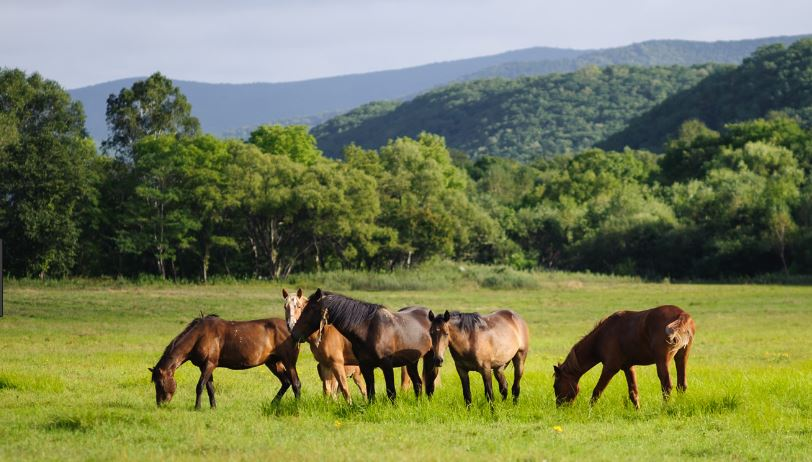

In [65]:
# Obtención de la imagen
img_path = "praderas.jpg"
image = Image.open(img_path).convert("RGB")
image

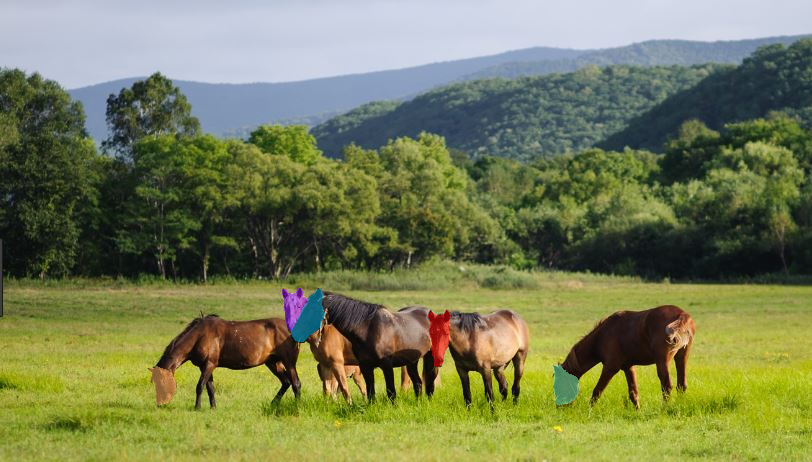

In [66]:
masks = ImageToImage(image, prompt)
new_img = overlay_masks(image, masks)
new_img

In [67]:
new_img.save('new_img.png')

In [68]:
# Obtener información de la imagen

img_path = 'new_img.png'

prompt = """Actúa como un asistente experto en accesibilidad visual. Te voy a proporcionar una imagen donde hay varios objetos resaltados explícitamente con colores vistosos.
            Tu objetivo es ayudar a una persona ciega a construir un mapa mental preciso de la escena. Por favor, sigue exactamente estos pasos:

            1. Describe en una sola oración el entorno general de la imagen (por ejemplo, 'Es una cocina vista desde el frente' o 'Es una calle concurrida').
            2. Por cada objeto resaltado que detectes, indica qué es y detalla su posición utilizando una cuadrícula imaginaria de 3x3 (arriba/centro/abajo y izquierda/centro/derecha).
            3. Si hay varios objetos resaltados, describe brevemente cómo están ubicados unos respecto a otros (ej. 'El objeto A está justo a la derecha y ligeramente por delante del objeto B').

            Ignora los objetos que no estén resaltados, a menos que sean un punto de referencia indispensable para ubicar a los que sí lo están. Sé claro, objetivo y preciso."""

text = ask_Groq(img_path=img_path, prompt=prompt)
text

'Es un prado con varios caballos pastando.\n\nHay cinco objetos resaltados: \n\n- Un objeto morado, que parece ser la cola de un caballo, en la posición centro-izquierda.\n- Un objeto azul turquesa, que parece ser la crin de un caballo, en la posición central.\n- Un objeto rojo, que parece ser la cabeza de un caballo, en la posición centro-derecha.\n- Un objeto verde azulado, que parece ser la cabeza de un caballo, en la posición derecha.\n\nEl objeto morado está a la izquierda del objeto azul turquesa. El objeto rojo y el objeto verde azulado están más a la derecha que el objeto azul turquesa. El objeto verde azulado está a la derecha de todos.'

In [69]:
TextToSpeech(text)